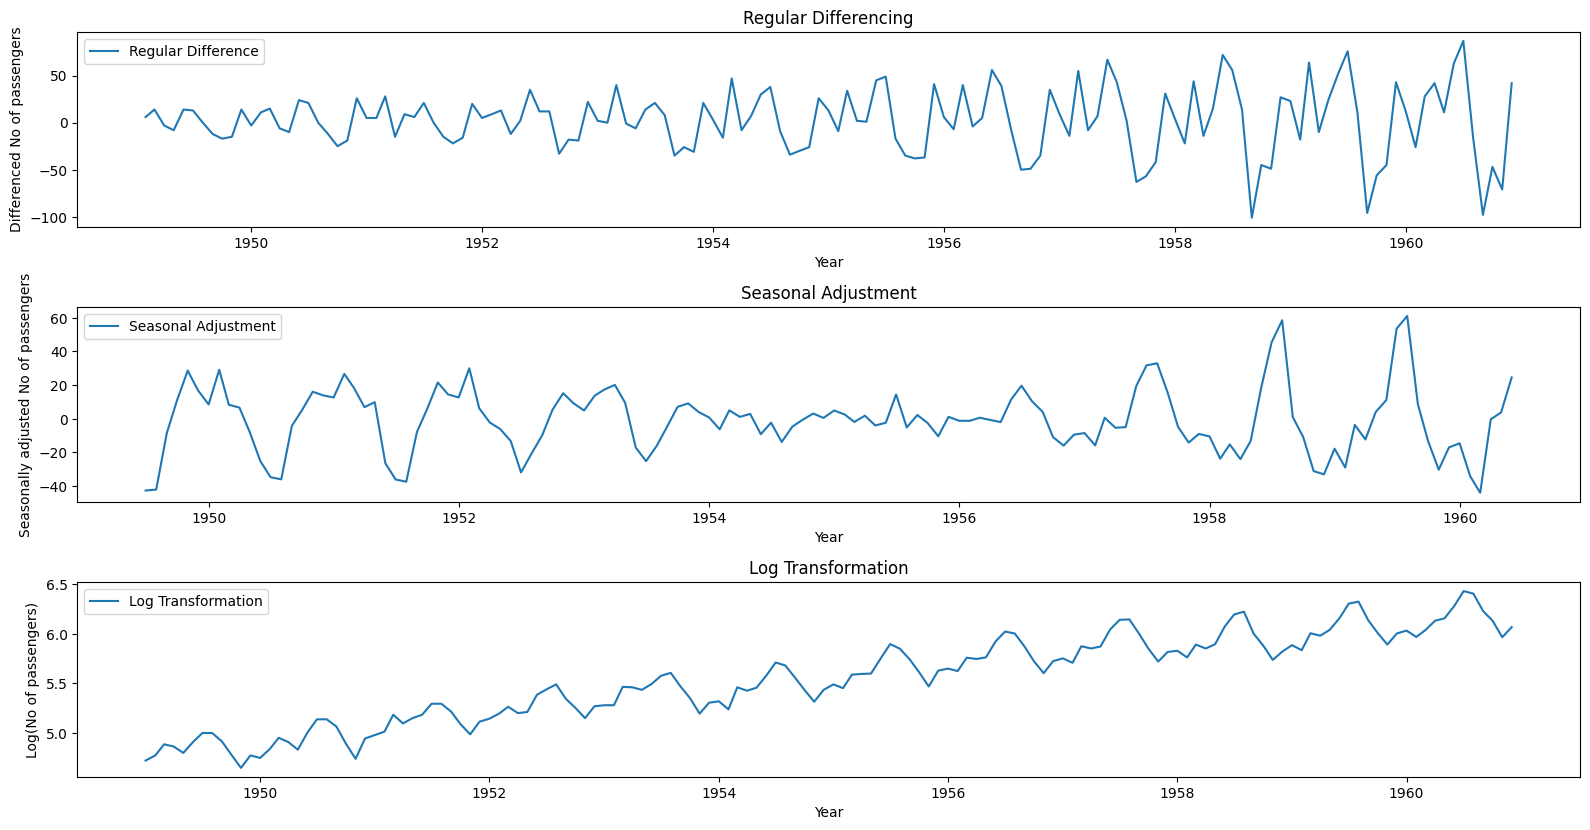

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose



data = pd.read_csv('/content/drive/MyDrive/COLAB PROJECTS/Time Series/AirPassengers.csv', parse_dates=['Month'])
data.set_index('Month', inplace=True)


data['passengers_diff'] = data['#Passengers'].diff()
data['passengers_log'] = np.log(data['#Passengers'])
data['passengers_log_diff'] = data['passengers_log'].diff()

data['passengers_sea_diff'] = seasonal_decompose(
    data['#Passengers'], model='additive', period=12
).resid

data['passengers_log_seasonal_diff'] = seasonal_decompose(
    data['passengers_log_diff'].dropna(), model='additive', period=12
).resid


plt.figure(figsize=(16, 16))

plt.subplot(6, 1, 2)
plt.plot(data['passengers_diff'], label='Regular Difference')
plt.title('Regular Differencing')
plt.xlabel('Year')
plt.ylabel('Differenced No of passengers')
plt.legend()

plt.subplot(6, 1, 3)
plt.plot(data['passengers_sea_diff'], label='Seasonal Adjustment')
plt.title('Seasonal Adjustment')
plt.xlabel('Year')
plt.ylabel('Seasonally adjusted No of passengers')
plt.legend()

plt.subplot(6, 1, 4)
plt.plot(data['passengers_log'], label='Log Transformation')
plt.title('Log Transformation')
plt.xlabel('Year')
plt.ylabel('Log(No of passengers)')
plt.legend()

plt.tight_layout()
plt.show()